# NAME: SEBA SAUD


In [8]:
!pip install autogluon.tabular seaborn --quiet

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

penguins = sns.load_dataset('penguins').dropna()

In [9]:
!pip install autogluon.tabular

# LOAD DATA


In [4]:
import seaborn as sns
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# First experiment:
X = Flipper Length (numerical) & Bill Length (numerical)
y = Species (categorical)

No path specified. Models will be saved in: "AutogluonModels/ag-20260422_112315"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.86 GB / 12.67 GB (85.7%)
Disk Space Avail:   86.94 GB / 107.72 GB (80.7%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ...
AutoGluon will save models to "/content/AutogluonModels/ag-20260422_112315"
Train Data Rows:    266
Train Data Columns: 3
Label Column:       species
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	3 unique label values:  ['Gentoo', 'Adelie', 'Chinstrap']
	If 'multiclass' is not the correct problem

,model,score_test,score_val
0,LightGBMLarge,1.000000,0.962963
1,NeuralNetTorch,1.000000,0.962963
2,LightGBMXT,1.000000,0.944444
3,RandomForestEntr,1.000000,0.925926
4,RandomForestGini,1.000000,0.925926
5,ExtraTreesGini,1.000000,0.962963
6,ExtraTreesEntr,1.000000,0.944444
7,NeuralNetFastAI,0.985075,0.981481
8,WeightedEnsemble_L2,0.985075,0.981481
9,XGBoost,0.985075,0.962963


Computing feature importance via permutation shuffling for 3 features using 67 rows with 5 shuffle sets...
	0.42s	= Expected runtime (0.08s per shuffle set)
	0.19s	= Actual runtime (Completed 5 of 5 shuffle sets)


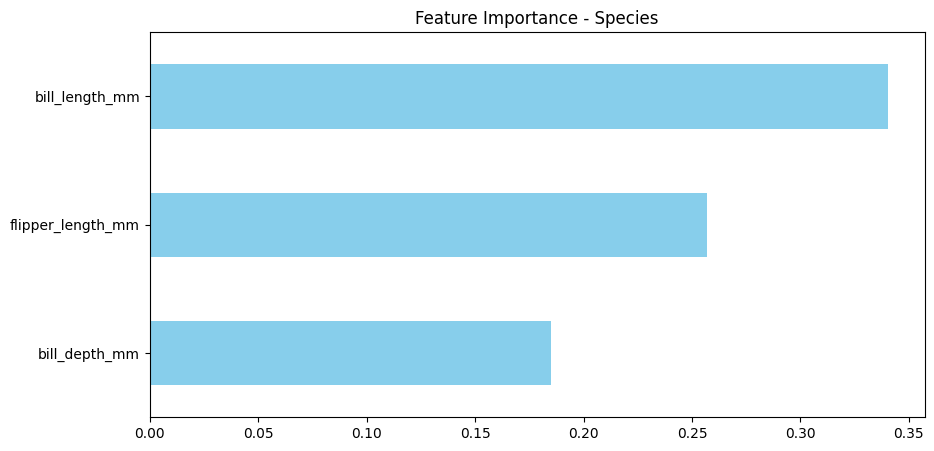

In [10]:
data_1 = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'species']]
train_1, test_1 = train_test_split(data_1, test_size=0.2, random_state=42)

predictor_1 = TabularPredictor(label='species').fit(train_1, presets='medium_quality')

lb_1 = predictor_1.leaderboard(test_1, silent=True)
display(lb_1[['model', 'score_test', 'score_val']].style.background_gradient(cmap='YlGnBu'))

importance_1 = predictor_1.feature_importance(test_1)
importance_1['importance'].sort_values().plot(kind='barh', color='skyblue', figsize=(10, 5))
plt.title('Feature Importance - Species')
plt.show()

predictor_1.save("model_species")

# Second experiment:
X = Weights (numerical) & Species (categorical)
y = Sex (categroical)


No path specified. Models will be saved in: "AutogluonModels/ag-20260422_112835"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.91 GB / 12.67 GB (86.1%)
Disk Space Avail:   86.93 GB / 107.72 GB (80.7%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ...
AutoGluon will save models to "/content/AutogluonModels/ag-20260422_112835"
Train Data Rows:    266
Train Data Columns: 2
Label Column:       sex
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['Female', 'Male']
	If 'binary' is not the correct problem_type, please manuall

,model,score_test,score_val
0,NeuralNetFastAI,0.880597,0.814815
1,LightGBM,0.865672,0.814815
2,LightGBMXT,0.865672,0.814815
3,ExtraTreesEntr,0.865672,0.759259
4,RandomForestGini,0.865672,0.759259
5,ExtraTreesGini,0.865672,0.759259
6,RandomForestEntr,0.865672,0.759259
7,NeuralNetTorch,0.850746,0.833333
8,WeightedEnsemble_L2,0.850746,0.833333
9,LightGBMLarge,0.835821,0.777778


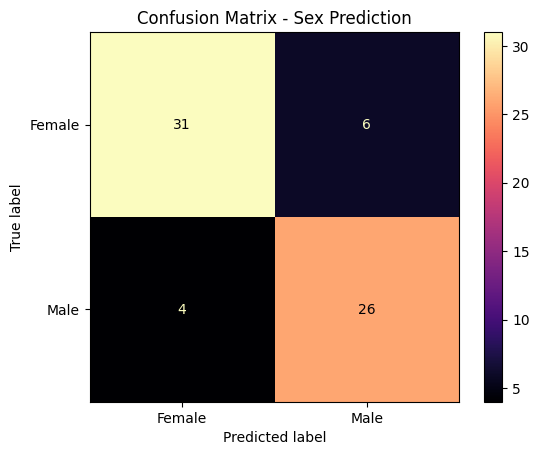

In [11]:
data_2 = penguins[['body_mass_g', 'species', 'sex']].dropna(subset=['sex'])
train_2, test_2 = train_test_split(data_2, test_size=0.2, random_state=42)

predictor_2 = TabularPredictor(label='sex').fit(train_2, presets='medium_quality')

lb_2 = predictor_2.leaderboard(test_2, silent=True)
display(lb_2[['model', 'score_test', 'score_val']].style.background_gradient(cmap='PuRd'))

y_pred_2 = predictor_2.predict(test_2)
ConfusionMatrixDisplay.from_predictions(test_2['sex'], y_pred_2, cmap='magma')
plt.title('Confusion Matrix - Sex Prediction')
plt.show()

predictor_2.save("model_sex")

#Third experiment:
X = island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
y = Sex and Species (multi-label classification)


In [12]:
features_3 = ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
targets = ['species', 'sex']

for target in targets:
    print(f"\n--- Training Process for Target: {target} ---")
    data_3 = penguins[features_3 + [target]].dropna()
    train_3, test_3 = train_test_split(data_3, test_size=0.2, random_state=42)

    model = TabularPredictor(label=target).fit(train_3, presets='medium_quality', time_limit=30)

    lb_3 = model.leaderboard(test_3, silent=True)
    display(lb_3[['model', 'score_test', 'score_val']].style.background_gradient(cmap='coolwarm'))

    model.save(f"model_final_{target}")

No path specified. Models will be saved in: "AutogluonModels/ag-20260422_113049"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.88 GB / 12.67 GB (85.8%)
Disk Space Avail:   86.92 GB / 107.72 GB (80.7%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'



--- Training Process for Target: species ---


Beginning AutoGluon training ... Time limit = 30s
AutoGluon will save models to "/content/AutogluonModels/ag-20260422_113049"
Train Data Rows:    266
Train Data Columns: 5
Label Column:       species
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	3 unique label values:  ['Gentoo', 'Adelie', 'Chinstrap']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       multiclass
Preprocessing data ...
Train Data Class Count: 3
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    11130.17 MB
	Train Data (Original)  Memory Usage: 0.02 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the 

,model,score_test,score_val
0,LightGBMLarge,1.000000,1.000000
1,LightGBMXT,1.000000,1.000000
2,LightGBM,1.000000,1.000000
3,NeuralNetTorch,1.000000,1.000000
4,NeuralNetFastAI,1.000000,1.000000
5,WeightedEnsemble_L2,1.000000,1.000000
6,RandomForestEntr,1.000000,0.944444
7,ExtraTreesGini,1.000000,1.000000
8,ExtraTreesEntr,1.000000,1.000000
9,RandomForestGini,1.000000,0.944444


No path specified. Models will be saved in: "AutogluonModels/ag-20260422_113102"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.87 GB / 12.67 GB (85.8%)
Disk Space Avail:   86.92 GB / 107.72 GB (80.7%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'



--- Training Process for Target: sex ---


Beginning AutoGluon training ... Time limit = 30s
AutoGluon will save models to "/content/AutogluonModels/ag-20260422_113102"
Train Data Rows:    266
Train Data Columns: 5
Label Column:       sex
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['Female', 'Male']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = Male, class 0 = Female
	Note: For your binary classification, AutoGluon arbitrarily selected which label-value represents positive (Male) vs negative (Female) class.
	To explicitly set the positive_class, either rename classes to 1 and 0, or specify positive_class in Predictor init.
Using Feature Generators to preprocess the data ...
Fitting AutoM

,model,score_test,score_val
0,ExtraTreesGini,0.925373,0.907407
1,LightGBMLarge,0.910448,0.907407
2,NeuralNetFastAI,0.910448,0.925926
3,ExtraTreesEntr,0.910448,0.907407
4,NeuralNetTorch,0.895522,0.907407
5,RandomForestEntr,0.895522,0.925926
6,RandomForestGini,0.895522,0.907407
7,LightGBM,0.880597,0.907407
8,XGBoost,0.880597,0.925926
9,LightGBMXT,0.820896,0.925926
